# Weather Classification Model — Training Notebook

## Setup Instructions

1. **Upload the dataset** — `weather_classification_data.csv` — using the Files
   panel on the left sidebar (folder icon → upload icon).
2. Run each cell top-to-bottom (`Shift+Enter`), or go to **Runtime → Run all**.
3. After the last cell completes, three files auto-download to your computer:
   - `weather_classifier.pkl`
   - `label_encoder.pkl`
   - `feature_importance.json`
4. Place all 3 files inside the project's `ml/` folder, then restart `uvicorn`.

For a faster run go to **Runtime → Change runtime type → T4 GPU**.


## Cell 2 — Install dependencies

In [1]:
!pip install xgboost==2.0.3 scikit-learn==1.4.2 pandas==2.2.2 \
            numpy==1.26.4 joblib==1.4.2 matplotlib==3.8.4 seaborn==0.13.2
print("All packages installed")


  Obtaining dependency information for xgboost==2.0.3 from https://files.pythonhosted.org/packages/24/ec/ad387100fa3cc2b9b81af0829b5ecfe75ec5bb19dd7c19d4fea06fb81802/xgboost-2.0.3-py3-none-win_amd64.whl.metadata
  Using cached xgboost-2.0.3-py3-none-win_amd64.whl.metadata (2.0 kB)
  Obtaining dependency information for scikit-learn==1.4.2 from https://files.pythonhosted.org/packages/40/77/91f92b2fddbd14201bf36cd0c0e7279f1501a88e7a00ef11261c4b95bb7a/scikit_learn-1.4.2-cp312-cp312-win_amd64.whl.metadata
  Using cached scikit_learn-1.4.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for pandas==2.2.2 from https://files.pythonhosted.org/packages/22/a5/a0b255295406ed54269814bc93723cfd1a0da63fb9aaf99e1364f07923e5/pandas-2.2.2-cp312-cp312-win_amd64.whl.metadata
  Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/16/2e/86f24451c2d530c88daf997cb8d6


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 3 — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
print("Imports complete")


Imports complete


## Cell 4 — Load & validate dataset

In [3]:
df = pd.read_csv('weather_classification_data.csv')
print(f" Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n Column names:")
print(df.columns.tolist())
print("\n First 5 rows:")
display(df.head())
print("\n Class distribution:")
print(df['Weather Type'].value_counts())
print("\n Missing values:")
print(df.isnull().sum())
print("\n Data types:")
print(df.dtypes)


 Dataset loaded: 13200 rows × 11 columns

 Column names:
['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location', 'Weather Type']

 First 5 rows:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy



 Class distribution:
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

 Missing values:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

 Data types:
Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object


## Cell 5 — Exploratory data analysis

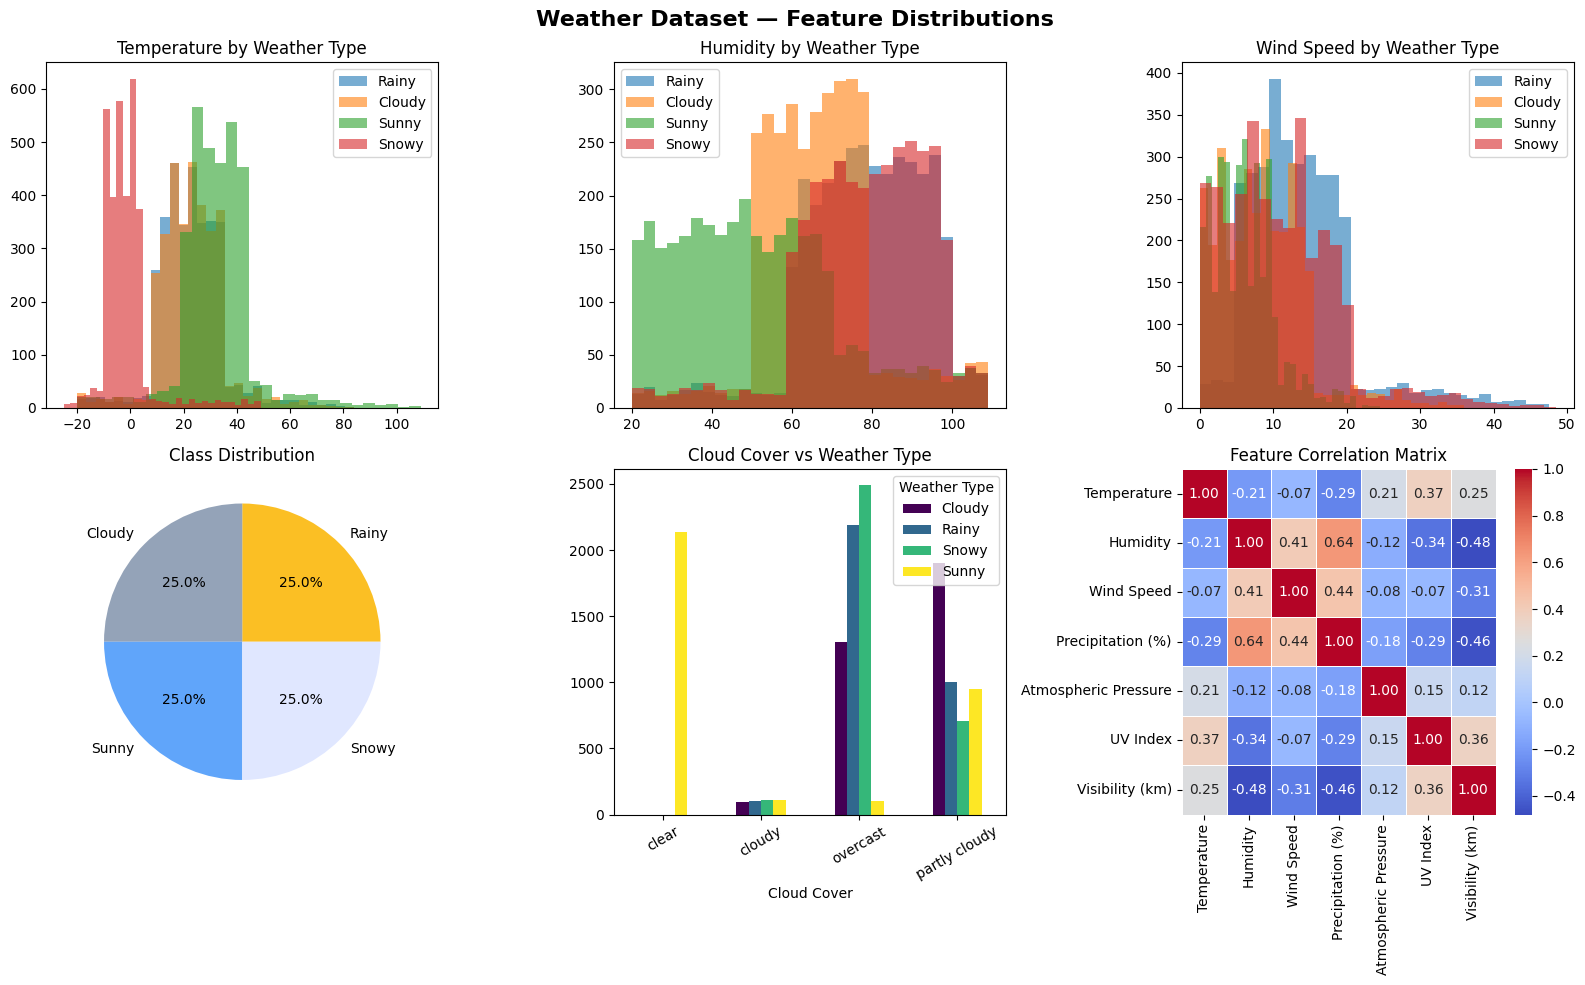

✅ EDA complete — plot saved as eda_plots.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Weather Dataset — Feature Distributions', fontsize=16, fontweight='bold')

for weather_type in df['Weather Type'].unique():
    subset = df[df['Weather Type'] == weather_type]
    axes[0,0].hist(subset['Temperature'], alpha=0.6, label=weather_type, bins=30)
axes[0,0].set_title('Temperature by Weather Type')
axes[0,0].legend()

for weather_type in df['Weather Type'].unique():
    subset = df[df['Weather Type'] == weather_type]
    axes[0,1].hist(subset['Humidity'], alpha=0.6, label=weather_type, bins=30)
axes[0,1].set_title('Humidity by Weather Type')
axes[0,1].legend()

for weather_type in df['Weather Type'].unique():
    subset = df[df['Weather Type'] == weather_type]
    axes[0,2].hist(subset['Wind Speed'], alpha=0.6, label=weather_type, bins=30)
axes[0,2].set_title('Wind Speed by Weather Type')
axes[0,2].legend()

class_counts = df['Weather Type'].value_counts()
axes[1,0].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
              colors=['#fbbf24','#94a3b8','#60a5fa','#e0e7ff'])
axes[1,0].set_title('Class Distribution')

cloud_counts = df.groupby(['Cloud Cover', 'Weather Type']).size().unstack(fill_value=0)
cloud_counts.plot(kind='bar', ax=axes[1,1], colormap='viridis')
axes[1,1].set_title('Cloud Cover vs Weather Type')
axes[1,1].tick_params(axis='x', rotation=30)

numeric_cols = ['Temperature','Humidity','Wind Speed','Precipitation (%)',
                'Atmospheric Pressure','UV Index','Visibility (km)']
corr = df[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
axes[1,2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA complete — plot saved as eda_plots.png")


## Cell 6 — Feature engineering & encoding

In [4]:
df_encoded = df.copy()

cloud_cover_map = {'clear': 0, 'partly cloudy': 1, 'cloudy': 2, 'overcast': 3}
df_encoded['Cloud Cover'] = df_encoded['Cloud Cover'].map(cloud_cover_map)

season_map = {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3}
df_encoded['Season'] = df_encoded['Season'].map(season_map)

location_map = {'inland': 0, 'coastal': 1, 'mountain': 2}
df_encoded['Location'] = df_encoded['Location'].map(location_map)

target_map = {'Sunny': 0, 'Cloudy': 1, 'Rainy': 2, 'Snowy': 3}
target_map_inverse = {v: k for k, v in target_map.items()}
df_encoded['Weather Type'] = df_encoded['Weather Type'].map(target_map)

label_encoders = {
    'cloud_cover': cloud_cover_map,
    'season': season_map,
    'location': location_map,
    'weather_type': target_map,
    'weather_type_inverse': target_map_inverse,
}

FEATURE_COLS = [
    'Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
    'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
    'Visibility (km)', 'Location'
]
TARGET_COL = 'Weather Type'

X = df_encoded[FEATURE_COLS]
y = df_encoded[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Feature engineering complete")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Test samples     : {X_test.shape[0]}")
print(f"   Features         : {FEATURE_COLS}")
print(f"\nEncoding maps saved: {list(label_encoders.keys())}")


Feature engineering complete
   Training samples : 10560
   Test samples     : 2640
   Features         : ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location']

Encoding maps saved: ['cloud_cover', 'season', 'location', 'weather_type', 'weather_type_inverse']


## Cell 7 — Train XGBoost with GridSearchCV

In [5]:
print("🔄 Building pipeline and running GridSearchCV...")
print("   This may take 5–15 minutes depending on Colab GPU/CPU...\n")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        use_label_encoder=False,
    )),
])

param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print(f"\nTraining complete!")
print(f"   Best params : {grid_search.best_params_}")
print(f"   Best CV acc : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")


🔄 Building pipeline and running GridSearchCV...
   This may take 5–15 minutes depending on Colab GPU/CPU...

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Training complete!
   Best params : {'xgb__learning_rate': 0.2, 'xgb__max_depth': 4, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}
   Best CV acc : 0.9177 (91.77%)


## Cell 8 — Evaluate model

  TEST ACCURACY: 0.9106 (91.06%)

Classification Report:
              precision    recall  f1-score   support

       Sunny       0.94      0.90      0.92       660
      Cloudy       0.88      0.90      0.89       660
       Rainy       0.88      0.92      0.90       660
       Snowy       0.95      0.92      0.93       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640



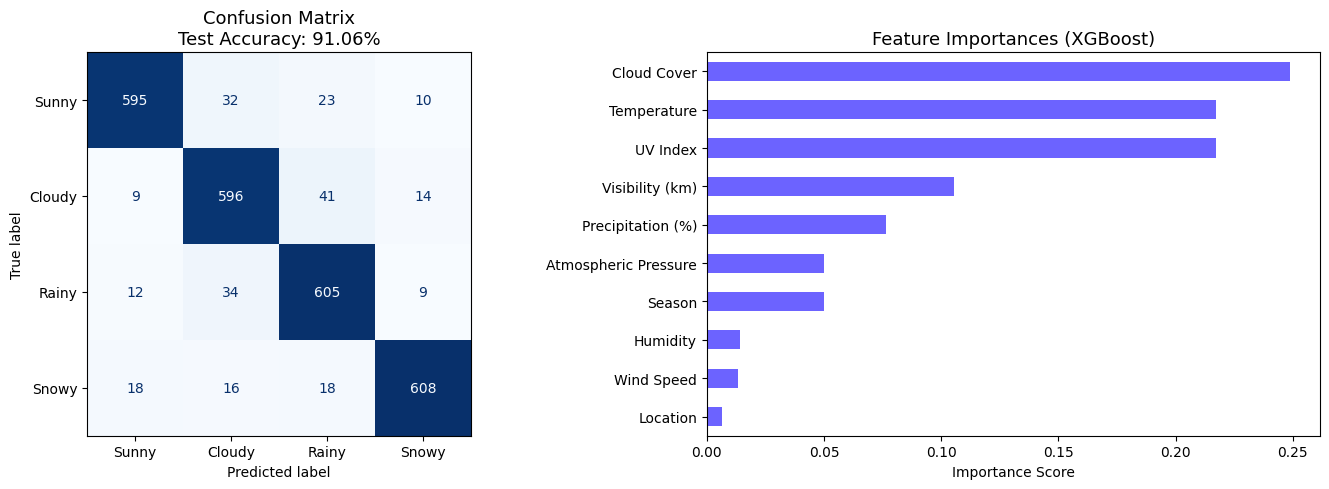


 5-Fold Cross-Validation: 0.9133 ± 0.0057
   Individual folds: ['0.9170', '0.9223', '0.9061', '0.9106', '0.9102']


In [6]:
y_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 55)
print(f"  TEST ACCURACY: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 55)
print("\nClassification Report:")
class_names = ['Sunny', 'Cloudy', 'Rainy', 'Snowy']
print(classification_report(y_test, y_pred, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\nTest Accuracy: {test_accuracy*100:.2f}%', fontsize=13)

xgb_model = best_pipeline.named_steps['xgb']
importances = xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='#6c63ff')
axes[1].set_title('Feature Importances (XGBoost)', fontsize=13)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='accuracy')
print(f"\n 5-Fold Cross-Validation: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Individual folds: {[f'{s:.4f}' for s in cv_scores]}")


## Cell 9 — Save model & auto-download

In [7]:
from google.colab import files

joblib.dump(best_pipeline, 'weather_classifier.pkl')
print("Saved: weather_classifier.pkl")

joblib.dump(label_encoders, 'label_encoder.pkl')
print("Saved: label_encoder.pkl")

xgb_model = best_pipeline.named_steps['xgb']
feat_importance_dict = {
    col: float(imp)
    for col, imp in sorted(
        zip(FEATURE_COLS, xgb_model.feature_importances_),
        key=lambda x: x[1], reverse=True
    )
}
with open('feature_importance.json', 'w') as f:
    json.dump(feat_importance_dict, f, indent=2)
print("Saved: feature_importance.json")

print("\n Downloading files to your computer...")
files.download('weather_classifier.pkl')
files.download('label_encoder.pkl')
files.download('feature_importance.json')

print("\nDone! Place all 3 files in your project's ml/ folder.")
print(f"\nFinal Summary:")
print(f"   Model        : XGBoost (best params: {grid_search.best_params_})")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   CV Accuracy  : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print(f"   Classes      : {class_names}")
print(f"   Features     : {len(FEATURE_COLS)} features")


ModuleNotFoundError: No module named 'google'